# Smart Handover — Treino do Modelo Multimodal
**Fase 2: Detecao de Frustracao (Texto + Audio)**

Este notebook treina o modelo de fusao multimodal e mostra graficos em tempo real.

## 1. Setup e Imports

In [1]:
import os, sys
import yaml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from tqdm.notebook import tqdm
from IPython.display import clear_output

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# Adicionar root do projecto ao path
sys.path.insert(0, os.path.abspath(".."))

from src.data.load_meld import load_meld, TARGET_LABELS
from src.models.fusion_model import MultimodalFusionModel, FocalLoss
from src.evaluation.metrics import compute_class_weights, compute_metrics, print_metrics
from src.training.train import collate_fn, validate

%matplotlib inline
plt.style.use("seaborn-v0_8-darkgrid")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

PyTorch: 2.7.1+cu118
CUDA: True — NVIDIA GeForce RTX 2060


## 2. Carregar Configuracao

In [2]:
config_path = os.path.join("..", "configs", "config.yaml")
with open(config_path) as f:
    config = yaml.safe_load(f)

# Mostrar config
print("=" * 50)
print("  CONFIGURACAO")
print("=" * 50)
print(f"  Batch size:        {config['training']['batch_size']}")
print(f"  Accumulation:      {config['training']['accumulation_steps']}")
print(f"  Effective batch:   {config['training']['batch_size'] * config['training']['accumulation_steps']}")
print(f"  Learning rate:     {config['training']['learning_rate']}")
print(f"  Epochs:            {config['training']['epochs']}")
print(f"  Freeze epochs:     {config['training']['freeze_epochs']}")
print(f"  Fusion type:       {config['fusion']['type']}")
print(f"  Weighted loss:     {config['training']['use_weighted_loss']}")
print(f"  Focal loss:        {config['training']['use_focal_loss']}")

device = torch.device(config["hardware"]["device"])
seed = config["hardware"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

  CONFIGURACAO
  Batch size:        2
  Accumulation:      16
  Effective batch:   32
  Learning rate:     2e-05
  Epochs:            40
  Freeze epochs:     2
  Fusion type:       concat
  Weighted loss:     False
  Focal loss:        True


## 3. Inicializar Modelo

In [3]:
print("A carregar modelos (RoBERTa + Wav2Vec2)...")
model = MultimodalFusionModel(config)
model.to(device)

tokenizer = model.text_encoder.get_tokenizer()
audio_processor = model.audio_encoder.get_processor()

# Contar parametros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParametros totais:    {total_params:,}")
print(f"Parametros treinaveis: {trainable_params:,}")

# Freeze se configurado
if config["training"]["freeze_encoders"]:
    model.freeze_encoders()
    trainable_after_freeze = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nApos freeze dos encoders:")
    print(f"Parametros treinaveis: {trainable_after_freeze:,} ({100*trainable_after_freeze/total_params:.1f}%)")

# VRAM
if torch.cuda.is_available():
    vram = torch.cuda.memory_allocated(device) / 1024**3
    print(f"\nVRAM usada: {vram:.2f} GB / 16 GB")

A carregar modelos (RoBERTa + Wav2Vec2)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\pedro\anaconda3\envs\DAA\Lib\site-packages\torch\nn\modules\module.py:1341: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(



Parametros totais:    219,808,391
Parametros treinaveis: 219,808,391

Apos freeze dos encoders:
Parametros treinaveis: 791,047 (0.4%)

VRAM usada: 0.82 GB / 16 GB


## 4. Carregar Dataset MELD

In [4]:
## 4. Carregar Dataset MELD
print("A carregar dataset MELD...")

from torch.utils.data import WeightedRandomSampler

max_text_length = config["data"]["max_text_length"]
max_audio_samples = config["data"]["max_audio_length_sec"] * config["data"]["audio_sample_rate"]
batch_size = config["training"]["batch_size"]

train_ds = load_meld("train", streaming=False)
val_ds = load_meld("validation", streaming=False)

_collate = partial(
    collate_fn,
    tokenizer=tokenizer,
    audio_processor=audio_processor,
    max_text_length=max_text_length,
    max_audio_samples=max_audio_samples,
)

# ---- NOVA LÓGICA DE BALANCEAMENTO (SAMPLER) ----
# 1. Contar as labels do dataset de treino
train_labels = [train_ds[i]["target_label"] for i in range(len(train_ds))]
class_counts = np.bincount(train_labels)

# 2. Calcular o peso de cada classe (inversamente proporcional à frequência)
pesos_classes = 1.0 / class_counts

# 3. Atribuir o peso correspondente a cada amostra individual
pesos_amostras = [pesos_classes[label] for label in train_labels]

# 4. Criar o Sampler
sampler = WeightedRandomSampler(
    weights=pesos_amostras, 
    num_samples=len(pesos_amostras), 
    replacement=True
)
# ------------------------------------------------

# ATENÇÃO: No train_loader, adicionámos o sampler e retirámos o shuffle=True
train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    sampler=sampler, 
    collate_fn=_collate, 
    num_workers=0, 
    pin_memory=True
)

val_loader = DataLoader(
    val_ds, 
    batch_size=batch_size, 
    shuffle=False,
    collate_fn=_collate, 
    num_workers=0, 
    pin_memory=True
)

print(f"Train: {len(train_ds)} amostras -> {len(train_loader)} batches (Com WeightedRandomSampler)")
print(f"Val:   {len(val_ds)} amostras -> {len(val_loader)} batches")

A carregar dataset MELD...
Train: 8783 amostras -> 4392 batches (Com WeightedRandomSampler)
Val:   958 amostras -> 479 batches


## 5. Visualizar Distribuicao de Classes + Pesos

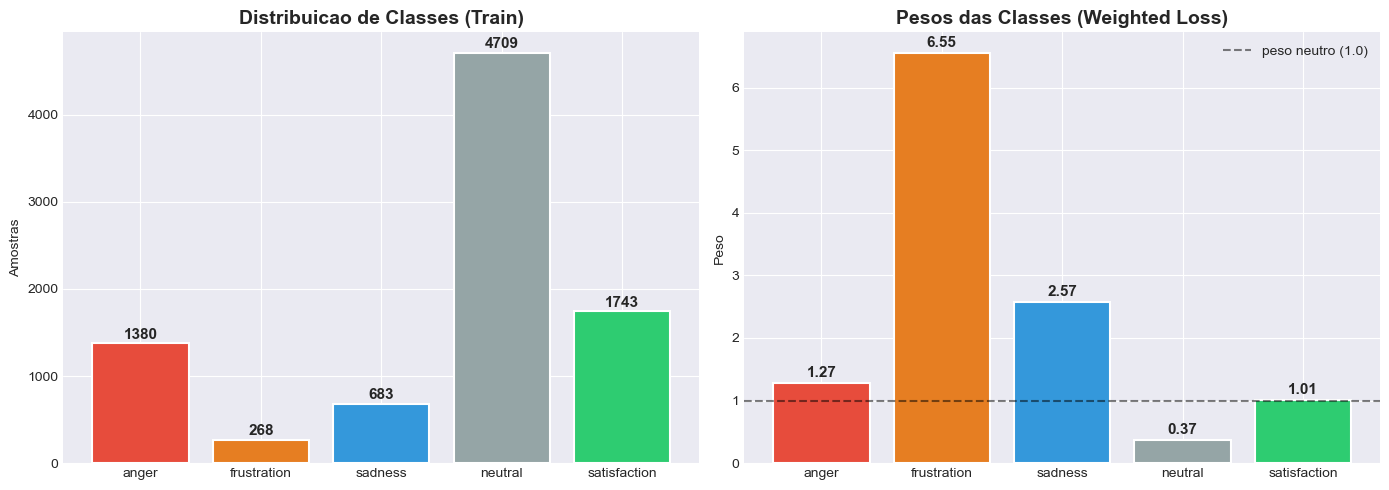

Grafico guardado em data/processed/class_distribution.png


In [ ]:
class_weights = compute_class_weights(train_ds).to(device)

from collections import Counter
counts = Counter(train_ds["target_emotion"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Distribuicao de classes
colors = ["#e74c3c", "#e67e22", "#3498db", "#95a5a6", "#2ecc71"]
class_counts = [counts.get(label, 0) for label in TARGET_LABELS]
bars = axes[0].bar(TARGET_LABELS, class_counts, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Distribuicao de Classes (Train)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Amostras")
for bar, count in zip(bars, class_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{count}", ha="center", fontsize=11, fontweight="bold")

# Grafico 2: Pesos das classes
weights_list = class_weights.cpu().tolist()
bars2 = axes[1].bar(TARGET_LABELS, weights_list, color=colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("Pesos das Classes (Weighted Loss)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Peso")
axes[1].axhline(y=1.0, color="black", linestyle="--", alpha=0.5, label="peso neutro (1.0)")
axes[1].legend()
for bar, w in zip(bars2, weights_list):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{w:.2f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join("..", "data", "processed", "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado em data/processed/class_distribution.png")

## 6. Configurar Loss, Optimizer e Scheduler

In [6]:
# Loss
if config["training"]["use_focal_loss"]:
    criterion = FocalLoss(
        weight=class_weights if config["training"]["use_weighted_loss"] else None,
        gamma=config["training"]["focal_gamma"],
    )
    print("Loss: Focal Loss")
else:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights if config["training"]["use_weighted_loss"] else None,
    )
    print("Loss: Weighted Cross-Entropy")

# Optimizer
def build_optimizer(model, config):
    lr = config["training"]["learning_rate"]
    encoder_lr = lr * config["training"]["encoder_lr_multiplier"]
    encoder_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "text_encoder.roberta" in name or "audio_encoder.wav2vec2" in name:
            encoder_params.append(param)
        else:
            head_params.append(param)
    return torch.optim.AdamW([
        {"params": head_params, "lr": lr},
        {"params": encoder_params, "lr": encoder_lr},
    ], weight_decay=config["training"]["weight_decay"])

optimizer = build_optimizer(model, config)

accum_steps = config["training"]["accumulation_steps"]
total_steps = (len(train_loader) // accum_steps) * config["training"]["epochs"]
warmup_steps = int(config["training"]["warmup_ratio"] * total_steps)

scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
scaler = torch.amp.GradScaler()

print(f"Optimizer: AdamW (head lr={config['training']['learning_rate']}, encoder lr={config['training']['learning_rate'] * config['training']['encoder_lr_multiplier']})")
print(f"Total steps: {total_steps}, Warmup: {warmup_steps}")
print(f"Gradient accumulation: {accum_steps} steps (effective batch={batch_size * accum_steps})")

Loss: Focal Loss
Optimizer: AdamW (head lr=2e-05, encoder lr=2.0000000000000003e-06)
Total steps: 10960, Warmup: 1096
Gradient accumulation: 16 steps (effective batch=32)


## 7. TREINO (com graficos ao vivo)

In [7]:
# Historico para graficos
history = {
    "train_loss": [],
    "val_loss": [],
    "accuracy": [],
    "weighted_f1": [],
    "macro_f1": [],
    "frustration_recall": [],
    "per_class_f1": {label: [] for label in TARGET_LABELS},
}

best_metric = -1.0  # comecar a -1 para garantir que o 1o epoch SEMPRE guarda
patience_counter = 0
patience = config["training"]["early_stopping_patience"]
max_grad_norm = config["training"]["max_grad_norm"]
freeze_epochs = config["training"]["freeze_epochs"]
num_epochs = config["training"]["epochs"]
checkpoint_dir = os.path.join("..", config["training"]["checkpoint_dir"])
os.makedirs(checkpoint_dir, exist_ok=True)


def plot_training_history(history, epoch):
    """Desenha graficos de treino actualizados."""
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    epochs_range = range(1, epoch + 2)

    # 1. Loss
    axes[0, 0].plot(epochs_range, history["train_loss"], "o-", label="Train", color="#e74c3c", linewidth=2)
    axes[0, 0].plot(epochs_range, history["val_loss"], "o-", label="Validation", color="#3498db", linewidth=2)
    axes[0, 0].set_title("Loss", fontsize=14, fontweight="bold")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Metricas globais
    axes[0, 1].plot(epochs_range, history["accuracy"], "o-", label="Accuracy", linewidth=2)
    axes[0, 1].plot(epochs_range, history["weighted_f1"], "s-", label="Weighted F1", linewidth=2)
    axes[0, 1].plot(epochs_range, history["macro_f1"], "^-", label="Macro F1", linewidth=2)
    axes[0, 1].set_title("Metricas Globais", fontsize=14, fontweight="bold")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend()
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Frustration Recall (METRICA CHAVE)
    axes[1, 0].plot(epochs_range, history["frustration_recall"], "o-",
                    color="#e67e22", linewidth=3, markersize=8)
    axes[1, 0].axhline(y=max(best_metric, 0), color="green", linestyle="--", alpha=0.7,
                        label=f"Melhor: {max(best_metric, 0):.4f}")
    axes[1, 0].set_title("Frustration Recall (METRICA CHAVE)", fontsize=14, fontweight="bold")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].legend(fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

    # 4. F1 por classe
    colors = ["#e74c3c", "#e67e22", "#3498db", "#95a5a6", "#2ecc71"]
    for label, color in zip(TARGET_LABELS, colors):
        axes[1, 1].plot(epochs_range, history["per_class_f1"][label], "o-",
                        label=label, color=color, linewidth=2)
    axes[1, 1].set_title("F1-Score por Classe", fontsize=14, fontweight="bold")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend()
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f"Epoch {epoch + 1}/{num_epochs}", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join("..", "data", "processed", "training_curves.png"), dpi=150, bbox_inches="tight")
    plt.show()


print(f"A iniciar treino: {num_epochs} epochs, early stopping por frustration_recall (patience={patience})")
print(f"Encoders congelados nas primeiras {freeze_epochs} epochs.")
print("=" * 60)

A iniciar treino: 40 epochs, early stopping por frustration_recall (patience=8)
Encoders congelados nas primeiras 2 epochs.


FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\processed\\training_curves.png'

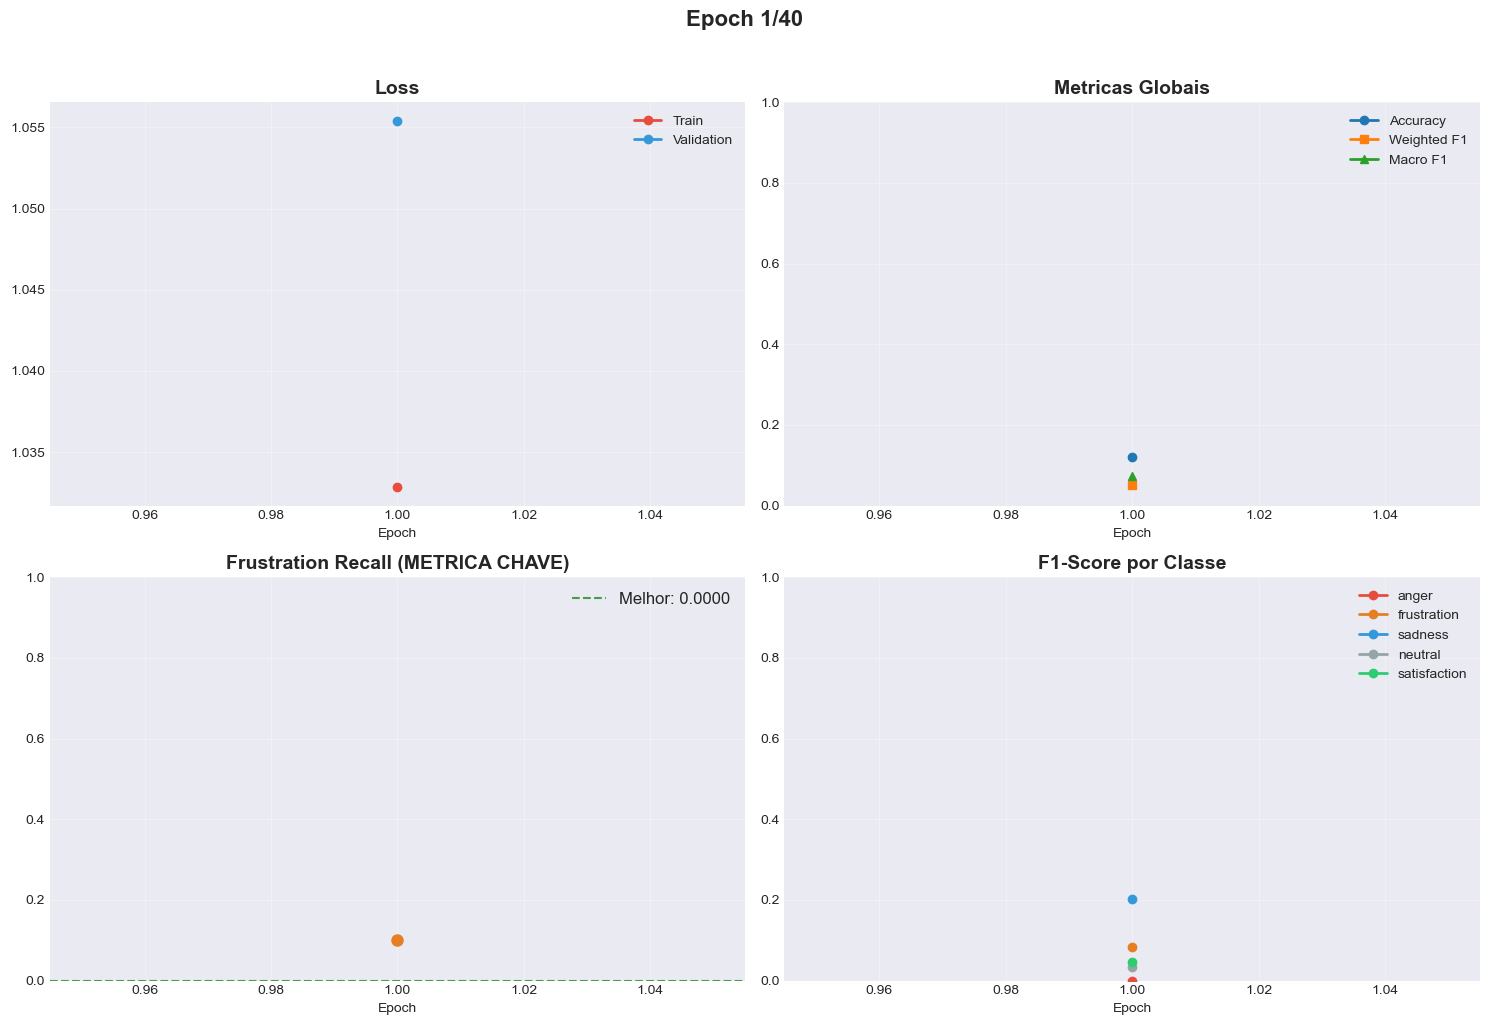

In [8]:
for epoch in range(num_epochs):

    # ---- Descongelar encoders no epoch certo ----
    if config["training"]["freeze_encoders"] and epoch == freeze_epochs:
        n = config["training"]["unfreeze_top_n_layers"]
        print(f"\n>> DESBLOQUEANDO top {n} camadas dos encoders!")
        model.unfreeze_encoders(n)
        optimizer = build_optimizer(model, config)
        remaining = (len(train_loader) // accum_steps) * (num_epochs - epoch)
        scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * remaining), remaining)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"   Parametros treinaveis agora: {trainable:,}")

    # ---- Treino ----
    model.train()
    optimizer.zero_grad()
    epoch_loss = 0.0

    progress = tqdm(enumerate(train_loader), total=len(train_loader),
                    desc=f"Epoch {epoch+1}/{num_epochs}")

    for step, batch in progress:
        text_ids = batch["text_input_ids"].to(device)
        text_mask = batch["text_attention_mask"].to(device)
        audio_vals = batch["audio_input_values"].to(device)
        audio_mask = batch["audio_attention_mask"]
        if audio_mask is not None:
            audio_mask = audio_mask.to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(text_ids, text_mask, audio_vals, audio_mask)
            loss = criterion(logits, labels) / accum_steps

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * accum_steps

        if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        progress.set_postfix({"loss": f"{loss.item() * accum_steps:.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)

    # ---- Validacao ----
    val_metrics = validate(model, val_loader, criterion, device)

    # ---- Guardar historico ----
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_metrics["val_loss"])
    history["accuracy"].append(val_metrics["accuracy"])
    history["weighted_f1"].append(val_metrics["weighted_f1"])
    history["macro_f1"].append(val_metrics["macro_f1"])
    history["frustration_recall"].append(val_metrics["frustration_recall"])
    for label in TARGET_LABELS:
        f1 = val_metrics["per_class"].get(label, {}).get("f1", 0.0)
        history["per_class_f1"][label].append(f1)

    # ---- Graficos ----
    plot_training_history(history, epoch)

    # ---- Print metricas ----
    print(f"\nEpoch {epoch+1}: train_loss={avg_train_loss:.4f} | val_loss={val_metrics['val_loss']:.4f}")
    print(f"  Accuracy={val_metrics['accuracy']:.4f} | W-F1={val_metrics['weighted_f1']:.4f} | "
          f"Macro-F1={val_metrics['macro_f1']:.4f} | Frust.Recall={val_metrics['frustration_recall']:.4f}")

    # ---- Early stopping ----
    current_metric = val_metrics["frustration_recall"]
    if current_metric > best_metric:
        best_metric = current_metric
        patience_counter = 0
        # Guardar melhor modelo
        ckpt_path = os.path.join(checkpoint_dir, "best_model.pt")
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "metrics": {k: v for k, v in val_metrics.items() if k != "confusion_matrix"},
            "history": history,
        }, ckpt_path)
        print(f"  >> NOVO MELHOR! Modelo guardado em {ckpt_path}")
    else:
        patience_counter += 1
        print(f"  Sem melhoria. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("\n>> EARLY STOPPING! O modelo nao melhora ha 5 epochs.")
            break

print(f"\nTreino concluido! Melhor frustration recall: {best_metric:.4f}")

## 8. Resultados Finais

In [9]:
# Carregar o melhor modelo
ckpt_path = os.path.join(checkpoint_dir, "best_model.pt")
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Melhor modelo carregado (epoch {checkpoint['epoch'] + 1})")
print(f"Metricas do melhor modelo:")
for k, v in checkpoint["metrics"].items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

Melhor modelo carregado (epoch 14)
Metricas do melhor modelo:
  accuracy: 0.4520
  weighted_f1: 0.4706
  macro_f1: 0.4197
  frustration_recall: 0.4000
  val_loss: 1.0333


In [10]:
# Avaliacao final no conjunto de TESTE
print("A avaliar no conjunto de TESTE (nunca visto pelo modelo)...")
test_ds = load_meld("test", streaming=False)

test_loader = DataLoader(
    test_ds, batch_size=batch_size, shuffle=False,
    collate_fn=_collate, num_workers=0, pin_memory=True
)

test_metrics = validate(model, test_loader, criterion, device)
print_metrics(test_metrics)

A avaliar no conjunto de TESTE (nunca visto pelo modelo)...


Map:   0%|          | 0/2610 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2610 [00:00<?, ? examples/s]


  Accuracy     : 0.4354
  Weighted F1  : 0.4636
  Macro F1     : 0.3822
  Frustration R: 0.3400  << KEY METRIC

  Class             Prec    Rec     F1  Support
  -------------------------------------------
  anger            0.472  0.506  0.488      413
  frustration      0.061  0.340  0.103       50 <<
  sadness          0.189  0.524  0.278      208
  neutral          0.873  0.316  0.464     1256
  satisfaction     0.491  0.701  0.578      402

  Confusion Matrix (rows=true, cols=pred):
            anger  frust  sadne  neutr  satis
    anger     209     44     78     21     61
    frust      12     17     14      2      5
    sadne      31     31    109     12     25
    neutr     140    177    341    397    201
    satis      51     11     35     23    282


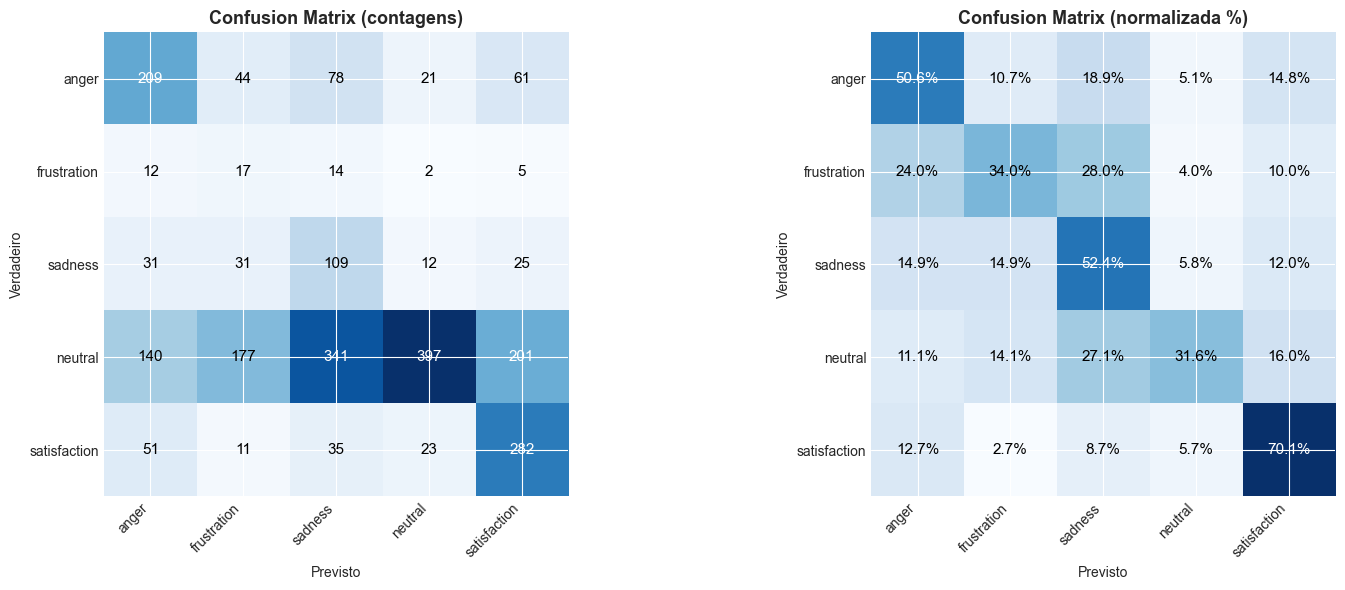

Guardado em data/processed/confusion_matrix.png


In [11]:
# Confusion Matrix visual
import matplotlib.colors as mcolors

cm = test_metrics["confusion_matrix"]
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, fmt in [
    (axes[0], cm, "Confusion Matrix (contagens)", "d"),
    (axes[1], cm_normalized, "Confusion Matrix (normalizada %)", ".1%"),
]:
    im = ax.imshow(data, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontsize=13, fontweight="bold")
    tick_marks = range(len(TARGET_LABELS))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(TARGET_LABELS, rotation=45, ha="right")
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(TARGET_LABELS)
    ax.set_ylabel("Verdadeiro")
    ax.set_xlabel("Previsto")

    for i in range(len(TARGET_LABELS)):
        for j in range(len(TARGET_LABELS)):
            val = data[i, j]
            text = format(val, fmt)
            color = "white" if data[i, j] > data.max() / 2 else "black"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join("..", "data", "processed", "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Guardado em data/processed/confusion_matrix.png")

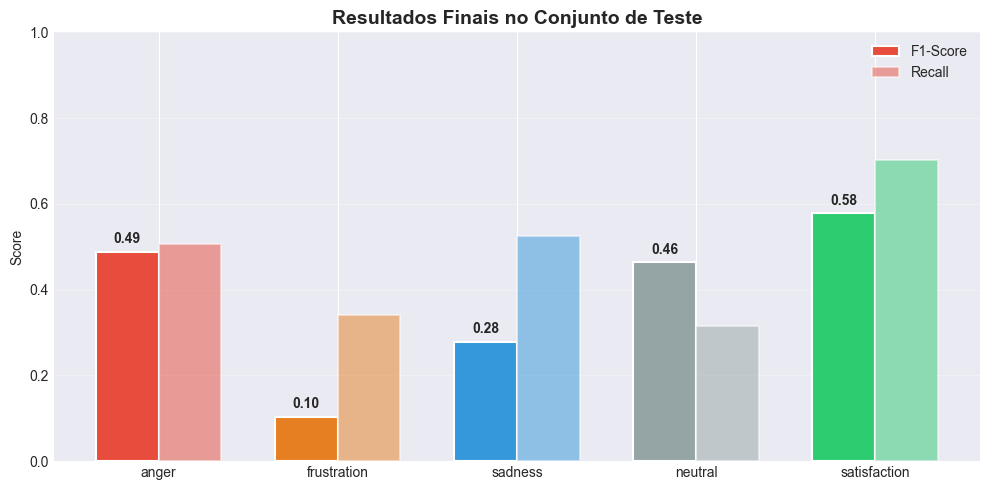


Resumo Final:
  Accuracy:           0.4354
  Weighted F1:        0.4636
  Macro F1:           0.3822
  Frustration Recall: 0.3400


In [12]:
# Grafico final: F1 por classe (barras)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c", "#e67e22", "#3498db", "#95a5a6", "#2ecc71"]
f1_scores = [test_metrics["per_class"][label]["f1"] for label in TARGET_LABELS]
recalls = [test_metrics["per_class"][label]["recall"] for label in TARGET_LABELS]

x = range(len(TARGET_LABELS))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], f1_scores, width, label="F1-Score", color=colors, edgecolor="white", linewidth=1.5)
bars2 = ax.bar([i + width/2 for i in x], recalls, width, label="Recall", color=colors, alpha=0.5, edgecolor="white", linewidth=1.5)

ax.set_title("Resultados Finais no Conjunto de Teste", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(TARGET_LABELS)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join("..", "data", "processed", "final_results.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nResumo Final:")
print(f"  Accuracy:           {test_metrics['accuracy']:.4f}")
print(f"  Weighted F1:        {test_metrics['weighted_f1']:.4f}")
print(f"  Macro F1:           {test_metrics['macro_f1']:.4f}")
print(f"  Frustration Recall: {test_metrics['frustration_recall']:.4f}")

---
**Modelo guardado em:** `checkpoints/best_model.pt`

**Graficos guardados em:** `data/processed/`
- `class_distribution.png`
- `training_curves.png`
- `confusion_matrix.png`
- `final_results.png`